In [1]:
import pandas as pd
import numpy as np
import os
import re
import string
import nltk
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from transformers import BertTokenizer, BertForSequenceClassification, AdamW, get_linear_schedule_with_warmup, BertModel, DataCollatorWithPadding
from torch.utils.data import DataLoader, Dataset, random_split
import torch
from tqdm import tqdm
import logging
import torch.nn as nn
import torch.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from transformers import LongformerForSequenceClassification
from transformers import LongformerTokenizer

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
df_annotations = pd.read_csv('/content/drive/My Drive/EHR_PROJ/DATA/ACTdb102003.csv')

In [4]:
mimic = pd.read_csv('/content/drive/My Drive/EHR_PROJ/DATA/NOTEEVENTS.csv')

<ipython-input-4-4a48a6fa372f>:1: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  mimic = pd.read_csv('/content/drive/My Drive/EHR_PROJ/DATA/NOTEEVENTS.csv')


In [5]:
# Build a list that contains all columns from df_annotations except BATCH.ID
column_list = [col for col in df_annotations.columns if col != 'BATCH.ID']
column_list.append('TEXT')

In [18]:
mimic_annotated = pd.merge(mimic, df_annotations, on = ['SUBJECT_ID', 'ROW_ID', 'HADM_ID'], how = 'inner')

In [19]:
mimic_annotated = mimic_annotated[column_list]

In [20]:
# prompt: Count number of words in clean_text

mimic_annotated['word_count'] = mimic_annotated['TEXT'].apply(lambda x: len(x.split()))
print(mimic_annotated['word_count'].describe())


count    2276.000000
mean     1524.487258
std       806.413491
min        37.000000
25%       989.250000
50%      1425.000000
75%      1916.000000
max      6150.000000
Name: word_count, dtype: float64


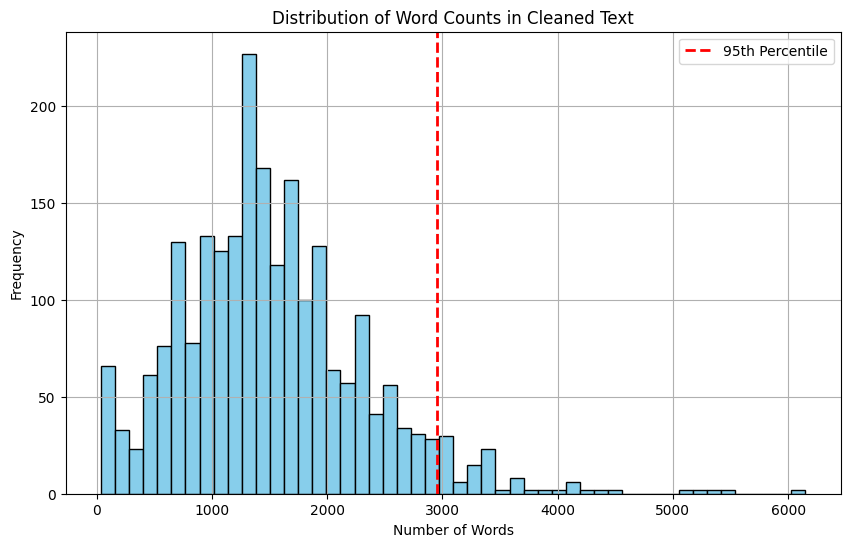

In [21]:
import matplotlib.pyplot as plt
# Plot number of words in clean_text. Mark 90% quantile

# Calculate the 90th percentile for word count
quantile_90 = mimic_annotated['word_count'].quantile(0.95)

# Plot the distribution of word counts
plt.figure(figsize=(10, 6))
plt.hist(mimic_annotated['word_count'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(quantile_90, color='red', linestyle='dashed', linewidth=2, label='95th Percentile')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Word Counts in Cleaned Text')
plt.legend()
plt.grid(True)
plt.show()


In [22]:
# prompt: count 0 and 1 in ADVANCED.CANCER	ADVANCED.HEART.DISEASE	ADVANCED.LUNG.DISEASE	ALCOHOL.ABUSE	CHRONIC.NEUROLOGICAL.DYSTROPHIES	CHRONIC.PAIN.FIBROMYALGIA	DEMENTIA	DEPRESSION	DEVELOPMENTAL.DELAY.RETARDATION	NON.ADHERENCE	NONE	OBESITY	OTHER.SUBSTANCE.ABUSE	SCHIZOPHRENIA.AND.OTHER.PSYCHIATRIC.DISORDERS	UNSURE columns

columns_to_count = ['ADVANCED.CANCER', 'ADVANCED.HEART.DISEASE', 'ADVANCED.LUNG.DISEASE', 'ALCOHOL.ABUSE',
                   'CHRONIC.NEUROLOGICAL.DYSTROPHIES', 'CHRONIC.PAIN.FIBROMYALGIA', 'DEMENTIA', 'DEPRESSION',
                   'DEVELOPMENTAL.DELAY.RETARDATION', 'NON.ADHERENCE', 'NONE', 'OBESITY', 'OTHER.SUBSTANCE.ABUSE',
                   'SCHIZOPHRENIA.AND.OTHER.PSYCHIATRIC.DISORDERS', 'UNSURE']

for column in columns_to_count:
  counts = mimic_annotated[column].value_counts()
  print(f"Column: {column}")
  if 0 in counts:
    print(f"Count of 0: {counts.get(0, 0)}")
  if 1 in counts:
    print(f"Count of 1: {counts.get(1, 0)}")
  print("-" * 20)


Column: ADVANCED.CANCER
Count of 0: 2166
Count of 1: 110
--------------------
Column: ADVANCED.HEART.DISEASE
Count of 0: 1923
Count of 1: 353
--------------------
Column: ADVANCED.LUNG.DISEASE
Count of 0: 2082
Count of 1: 194
--------------------
Column: ALCOHOL.ABUSE
Count of 0: 2070
Count of 1: 206
--------------------
Column: CHRONIC.NEUROLOGICAL.DYSTROPHIES
Count of 0: 1934
Count of 1: 342
--------------------
Column: CHRONIC.PAIN.FIBROMYALGIA
Count of 0: 1979
Count of 1: 297
--------------------
Column: DEMENTIA
Count of 0: 2171
Count of 1: 105
--------------------
Column: DEPRESSION
Count of 0: 1726
Count of 1: 550
--------------------
Column: DEVELOPMENTAL.DELAY.RETARDATION
Count of 0: 2236
Count of 1: 40
--------------------
Column: NON.ADHERENCE
Count of 0: 2127
Count of 1: 149
--------------------
Column: NONE
Count of 0: 1551
Count of 1: 725
--------------------
Column: OBESITY
Count of 0: 2133
Count of 1: 143
--------------------
Column: OTHER.SUBSTANCE.ABUSE
Count of 0: 21

In [24]:
# potential_cols = ['ALCOHOL.ABUSE', 'NON.ADHERENCE', 'OBESITY', 'OTHER.SUBSTANCE.ABUSE', 'SCHIZOPHRENIA.AND.OTHER.PSYCHIATRIC.DISORDERS', 'DEPRESSION', 'CHRONIC.PAIN.FIBROMYALGIA', 'DEVELOPMENTAL.DELAY.RETARDATION']
# potential_cols = ['ALCOHOL.ABUSE', 'NON.ADHERENCE', 'OBESITY', 'OTHER.SUBSTANCE.ABUSE', 'SCHIZOPHRENIA.AND.OTHER.PSYCHIATRIC.DISORDERS', 'DEPRESSION']
# potential_cols = ['ALCOHOL.ABUSE', 'DEMENTIA', 'DEPRESSION', 'DEVELOPMENTAL.DELAY.RETARDATION', 'NON.ADHERENCE', 'OBESITY', 'OTHER.SUBSTANCE.ABUSE', 'SCHIZOPHRENIA.AND.OTHER.PSYCHIATRIC.DISORDERS']
# potential_cols = ['ALCOHOL.ABUSE', 'NON.ADHERENCE', 'OBESITY', 'OTHER.SUBSTANCE.ABUSE', 'SCHIZOPHRENIA.AND.OTHER.PSYCHIATRIC.DISORDERS']
potential_cols = ['ALCOHOL.ABUSE', 'NON.ADHERENCE', 'OTHER.SUBSTANCE.ABUSE']


In [12]:
'''
# prompt: count number of 1 in potential_cols and create a new column to record the number.

mimic_annotated['count_of_1'] = mimic_annotated[potential_cols + ['NONE']].sum(axis=1)
print(mimic_annotated['count_of_1'].value_counts())

# prompt: keep only rows with count_of_1 is none zero in mimic_annotated

mimic_annotated = mimic_annotated[mimic_annotated['count_of_1'] != 0]
'''

count_of_1
1    1229
0     847
2     145
3      49
4       6
Name: count, dtype: int64


In [14]:
# mimic_annotated[potential_cols + ['NONE', 'count_of_1']]

,ALCOHOL.ABUSE,NON.ADHERENCE,OBESITY,OTHER.SUBSTANCE.ABUSE,SCHIZOPHRENIA.AND.OTHER.PSYCHIATRIC.DISORDERS,NONE,count_of_1
0,0,0,0,0,0,1,1
2,0,0,0,0,0,1,1
6,0,0,0,0,0,1,1
8,0,0,0,0,0,1,1
9,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...
2270,1,0,0,0,0,0,1
2271,1,0,0,1,0,0,2
2273,0,0,0,0,1,0,1
2274,0,0,0,0,0,1,1


In [15]:
'''
# create another dataframe called mimic_annotated_final and create a new column called "label". Make the label to be 1 as long as any of the columns in potential_cols to be 1. otherwise 0

mimic_annotated_final = mimic_annotated.copy()
mimic_annotated_final['label'] = 0
for col in potential_cols:
  mimic_annotated_final.loc[mimic_annotated_final[col] == 1, 'label'] = 1
'''

'\n# create another dataframe called mimic_annotated_final and create a new column called "label". Make the label to be 1 as long as any of the columns in potential_cols to be 1. otherwise 0\n\nmimic_annotated_final = mimic_annotated.copy()\nmimic_annotated_final[\'label\'] = 0\nfor col in potential_cols:\n  mimic_annotated_final.loc[mimic_annotated_final[col] == 1, \'label\'] = 1\n'

In [25]:
# create another dataframe called mimic_annotated_final and create a new column called "label". Make the label to be 1 as long as any of the columns in potential_cols to be 1. otherwise 0

mimic_annotated_final = mimic_annotated.copy()
mimic_annotated_final['label'] = 0
for col in potential_cols:
  mimic_annotated_final.loc[mimic_annotated_final[col] == 1, 'label'] = 1


In [17]:
mimic_annotated_final['label'].value_counts()

,count
label,
0,723
1,706


In [26]:
# prompt: For mimic_annotated_final dataframe, if label is 1, remove duplicated if HADM_ID, SUBJECT_ID, and ROW_ID are all the same

mimic_annotated_final = mimic_annotated_final.drop_duplicates(subset=['HADM_ID', 'SUBJECT_ID', 'ROW_ID', 'label'], keep='first')

In [27]:
# prompt: If HADM_ID, SUBJECT_ID, and ROW_ID are the same, keep label that is 1

mimic_annotated_final = mimic_annotated_final.sort_values(['HADM_ID', 'SUBJECT_ID', 'ROW_ID', 'label'], ascending=[True, True, True, False])
mimic_annotated_final = mimic_annotated_final.drop_duplicates(subset=['HADM_ID', 'SUBJECT_ID', 'ROW_ID'], keep='first')


In [28]:
mimic_annotated_final['label'].value_counts()

,count
label,
0,646
1,198


In [29]:
mimic_annotated_final[potential_cols + ['label']]

,ALCOHOL.ABUSE,NON.ADHERENCE,OTHER.SUBSTANCE.ABUSE,label
748,0,0,0,0
1729,0,0,0,0
1733,0,0,0,0
497,0,0,0,0
1214,0,0,0,0
...,...,...,...,...
999,0,0,0,0
1340,0,0,0,0
202,0,0,0,0
1048,1,1,0,1


In [30]:
# prompt: check duplicates for mimic_annotated_final subset is TEXT

# Check for duplicates based on 'TEXT' column in mimic_annotated_final
duplicate_texts = mimic_annotated_final[mimic_annotated_final.duplicated(subset=['TEXT'], keep=False)]

if not duplicate_texts.empty:
    print("Duplicate TEXT entries found:")
    print(duplicate_texts[['TEXT', 'HADM_ID', 'SUBJECT_ID', 'ROW_ID']])
else:
    print("No duplicate TEXT entries found.")

No duplicate TEXT entries found.


In [31]:
# count percentage of label being 1

total_rows = len(mimic_annotated_final)
label_1_count = mimic_annotated_final['label'].sum()
percentage_label_1 = (label_1_count / total_rows) * 100

print(f"Percentage of label being 1: {percentage_label_1:.2f}%")


Percentage of label being 1: 23.46%


In [32]:
# For mimic_annotated_final, keep only TEXT and label
mimic_annotated_final = mimic_annotated_final[['TEXT', 'label']]


In [33]:
texts = mimic_annotated_final['TEXT'].to_numpy()
labels = mimic_annotated_final['label'].to_numpy()

# Split the data into training and validation sets (80% train, 20% val)
train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.2, stratify=labels, random_state=42)

In [34]:
# Save train_texts, val_texts, train_labels, val_labels to DATA as csv

# Create DataFrames from the lists
train_df = pd.DataFrame({'text': train_texts, 'label': train_labels})
val_df = pd.DataFrame({'text': val_texts, 'label': val_labels})

# Save the DataFrames to CSV files
train_df.to_csv('/content/drive/My Drive/EHR_PROJ/DATA/train_data_phenotype.csv', index=False)
val_df.to_csv('/content/drive/My Drive/EHR_PROJ/DATA/val_data_phenotype.csv', index=False)


In [35]:
train_df

,text,label
0,Admission Date: [**2169-3-12**] ...,1
1,Admission Date: [**2186-2-6**] Discharg...,0
2,Admission Date: [**2188-4-1**] Discharg...,0
3,Admission Date: [**2152-9-12**] ...,1
4,Admission Date: [**2184-6-11**] Dischar...,1
...,...,...
670,Admission Date: [**2163-9-4**] D...,0
671,Admission Date: [**2204-1-5**] D...,0
672,Admission Date: [**2179-5-11**] Dischar...,0
673,Admission Date: [**2170-5-2**] Discharg...,1


In [36]:
train_df['label'].value_counts()

,count
label,
0,517
1,158
